# Import

In [14]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts
import snspd4

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 459


# Parameters

In [15]:
params = snspd4.snspd4()

In [6]:
ID = 450 
data = load_by_id(450).get_parameter_data()
CR1 = data['CR1']['CR1'][1]
CR2 = data['CR2']['CR2'][1]

print(CR1)

nan


13.3866666666667
13.3966666666667


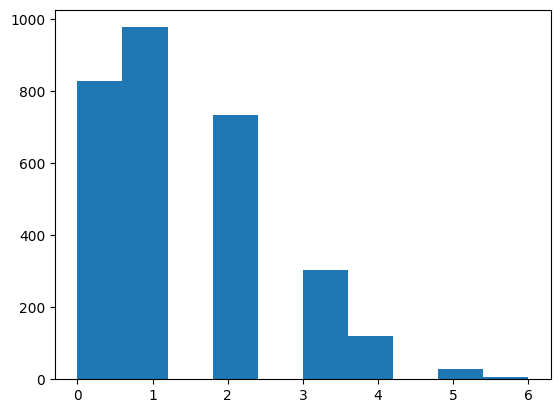

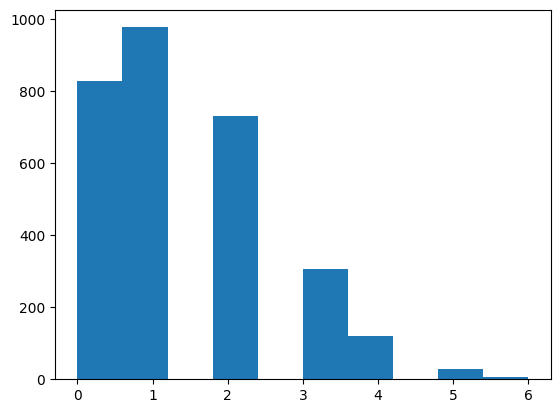

In [12]:
ID = 454
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1'][0]
CR2 = data['CR2']['CR2'][0]
counts1 = data['counts1']['counts1']
counts2 = data['counts2']['counts2']
total_counts1 = data['total_counts1']['total_counts1']
total_counts2 = data['total_counts2']['total_counts2']

plt.hist(counts1)
plt.figure()
plt.hist(counts2)

print(CR1)
print(CR2)

In [17]:
data

{'CR1': {'CR1': array([12.31666667,         nan,         nan, ...,         nan,
                 nan,         nan], shape=(3000,)),
  'index': array([   0,    1,    2, ..., 2997, 2998, 2999], shape=(3000,))},
 'CR2': {'CR2': array([12.31666667,         nan,         nan, ...,         nan,
                 nan,         nan], shape=(3000,)),
  'index': array([   0,    1,    2, ..., 2997, 2998, 2999], shape=(3000,))},
 'counts1': {'counts1': array([1., 1., 1., ..., 0., 2., 1.], shape=(3000,)),
  'index': array([   0,    1,    2, ..., 2997, 2998, 2999], shape=(3000,))},
 'counts2': {'counts2': array([1., 1., 1., ..., 0., 2., 1.], shape=(3000,)),
  'index': array([   0,    1,    2, ..., 2997, 2998, 2999], shape=(3000,))},
 'dmm_volt': {'dmm_volt': array([9.08463712e-07,            nan,            nan, ...,
                    nan,            nan,            nan], shape=(3000,)),
  'index': array([   0,    1,    2, ..., 2997, 2998, 2999], shape=(3000,))},
 'interval': {'interval': array([ 1.,

12.3166666666667
12.3166666666667


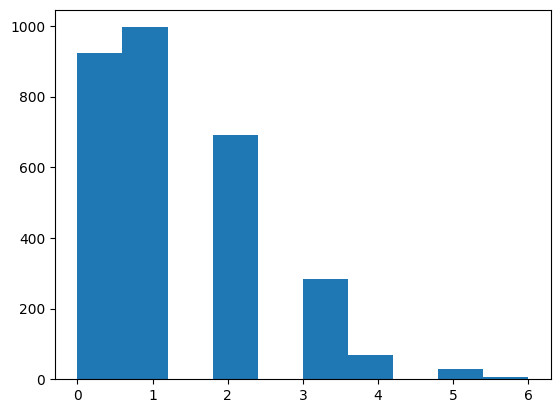

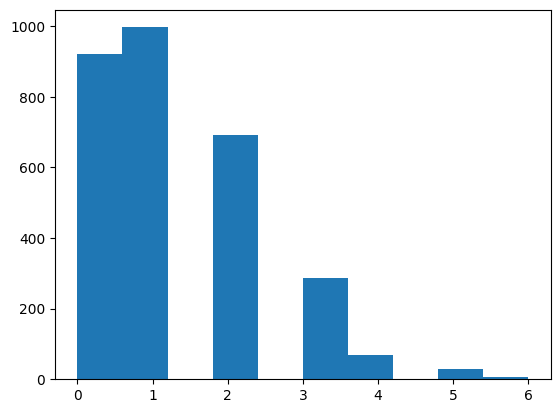

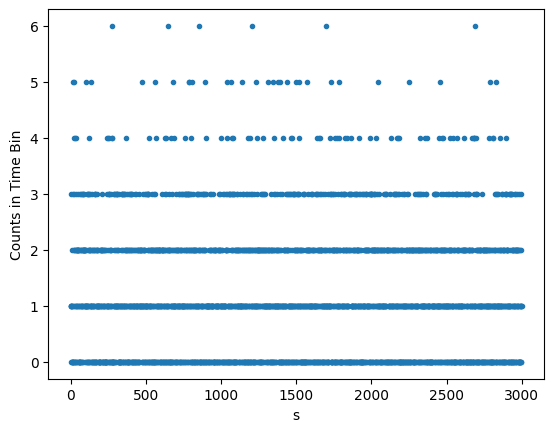

In [24]:
ID = params.system_dark_counts_id
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1'][0]
CR2 = data['CR2']['CR2'][0]
counts1 = data['counts1']['counts1']
counts2 = data['counts2']['counts2']
total_counts1 = data['total_counts1']['total_counts1']
total_counts2 = data['total_counts2']['total_counts2']
current = data['yoko_current']['yoko_current']

plt.hist(counts1)
plt.figure()
plt.hist(counts2)

plt.figure()
plt.plot(counts1, '.') 
plt.xlabel('s')
plt.ylabel('Counts in Time Bin')

print(CR1)
print(CR2)